In [2]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.pyplot as plt

from brainspace.utils.parcellation import map_to_labels, reduce_by_labels
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import pingouin



In [3]:
bids_folder_numrisk = '/mnt_04/ds-numrisk' 
bids_folder_dnumrisk = '/mnt_03/ds-dnumrisk'

plot_folder = op.join(bids_folder_numrisk, 'plots_and_ims/gradient_stuff')




In [4]:
# get masks
surf_mask_L = op.join(bids_folder_dnumrisk, 'derivatives/surface_masks', 'desc-NPC_L_space-fsaverage5_hemi-lh.label.gii')
surf_mask_L = nib.load(surf_mask_L).agg_data()
surf_mask_R = op.join(bids_folder_dnumrisk, 'derivatives/surface_masks', 'desc-NPC_R_space-fsaverage5_hemi-rh.label.gii')
surf_mask_R = nib.load(surf_mask_R).agg_data()
nprf_r2 = np.concatenate((surf_mask_L, surf_mask_R))

#mask, labeling_noParcel = get_basic_mask()
#nprf_r2_mask = np.bool_(nprf_r2[mask])
nprf_r2 = np.bool_(nprf_r2)

np.shape(nprf_r2)


(20484,)

## NPC-mask gradients from numrisk

In [5]:
from os import listdir
subList = [f[4:6] for f in listdir(op.join(bids_folder_numrisk)) if f[0:4] == 'sub-'] # and len(f)==6]
subList.remove('1')
subList.remove('0')
fsaverage = fetch_surf_fsaverage('fsaverage5') 

phenotype_folder = op.join(bids_folder_numrisk, 'derivatives','phenotype')
if not op.isdir(phenotype_folder):
    os.makedirs(phenotype_folder)

In [6]:
## load in gradients
bids_folder = bids_folder_numrisk

n_gradients = 5
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm = op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}')
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy'))
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])
dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms_aligned[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')

In [26]:
# take NPC as a network and compute dispersion
n_grad = 2
g1 = np.array(gms_aligned[f'g{n_grad}']).T # n_vertices x n_subjects

# get the gradient loadings of the nodes of the ROI, for each subject (shape: number of nodes in network x N)
G1_net = g1[nprf_r2]

centroid_cog_net = np.nanmedian(G1_net, axis=0)  #np.median(G1_net, axis=0)  
dist_nodes_to_centroid = G1_net - centroid_cog_net  # shape: number of nodes in network x N

NPC_dispersion = np.nanmean((dist_nodes_to_centroid**2), axis = 0) 

df_mig = pd.DataFrame(np.array([NPC_dispersion, centroid_cog_net]).T, index=sub_array, columns=['NPC_dispersion', 'NPC_centroid'])
df_mig.index.name = 'subject'
df_mig.sort_index(inplace=True)
#df_mig.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}.csv'))
df_mig['dataset'] = 'miguel'
df_mig.set_index(['dataset'], append=True, inplace=True)
df_mig.head()


,,NPC_dispersion,NPC_centroid
subject,dataset,,
2,miguel,3.576422,1.238944
3,miguel,6.563879,1.519308
4,miguel,1.920423,1.481296
5,miguel,5.644927,2.189734
6,miguel,10.058537,1.716826


## Load in neural data

In [19]:
# load in Miguels withinNdispersion-NPC measures
n_grad = 2
phenotype_folder = op.join(bids_folder_numrisk, 'derivatives','phenotype')

df_mig = pd.read_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}.csv'))
df_mig['dataset'] = 'miguel'
df_mig.set_index(['subject','dataset'], inplace=True)
df_mig.head()


,,NPC_dispersion,NPC_centroid
subject,dataset,,
2,miguel,3.576422,1.238944
3,miguel,6.563879,1.519308
4,miguel,1.920423,1.481296
5,miguel,5.644927,2.189734
6,miguel,10.058537,1.716826


In [20]:
# load in dyscalc withinNdispersion-NPC measures
phenotype_folder = op.join(bids_folder_dnumrisk, 'derivatives','phenotype')

df_dyscalc = pd.read_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}.csv'))
df_dyscalc['dataset'] = 'dyscalc'
df_dyscalc.set_index(['subject','dataset'], inplace=True)

df_dyscalc.head()


,,group,NPC_dispersion,NPC_centroid
subject,dataset,,,
21,dyscalc,0,11.874677,1.504974
59,dyscalc,0,2.687693,1.923676
54,dyscalc,0,6.611221,2.240979
15,dyscalc,0,15.730722,1.744303
52,dyscalc,0,3.709795,0.589167


In [62]:
df_neuro = pd.concat([df_mig, df_dyscalc])
df_neuro.loc[pd.isna(df_neuro['group']), 'group'] = 'control_miguel'
df_neuro.loc[df_neuro['group'] == 0, 'group'] = 'control_dyscalc'
df_neuro.loc[df_neuro['group'] == 1, 'group'] = 'dyscalc'

df_neuro.head()

/tmp/ipykernel_1776448/3420992082.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'control_miguel' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_neuro.loc[pd.isna(df_neuro['group']), 'group'] = 'control_miguel'


,,NPC_dispersion,NPC_centroid,group
subject,dataset,,,
2,miguel,3.576422,1.238944,control_miguel
3,miguel,6.563879,1.519308,control_miguel
4,miguel,1.920423,1.481296,control_miguel
5,miguel,5.644927,2.189734,control_miguel
6,miguel,10.058537,1.716826,control_miguel


## Behavioral data

In [28]:
from utils_02 import get_behave_bauer_params

df_behave_dyscalc = get_behave_bauer_params(bids_folder=bids_folder_dnumrisk, dataset='dyscalc',unbiased=False)
df_behave_mig = get_behave_bauer_params(bids_folder=bids_folder_numrisk, dataset='miguel',unbiased=True)

df_behave = pd.concat([df_behave_mig, df_behave_dyscalc])
df_behave = df_behave.drop(columns='group')
df_behave.head()

,,perceptual_noise_sd,memory_noise_sd
subject,dataset,,
1,miguel,0.119338,0.164649
2,miguel,0.144083,0.141128
3,miguel,0.159790,0.204653
4,miguel,0.165733,0.240002
5,miguel,0.145187,0.252977


<Axes: xlabel='NPC_dispersion', ylabel='Density'>

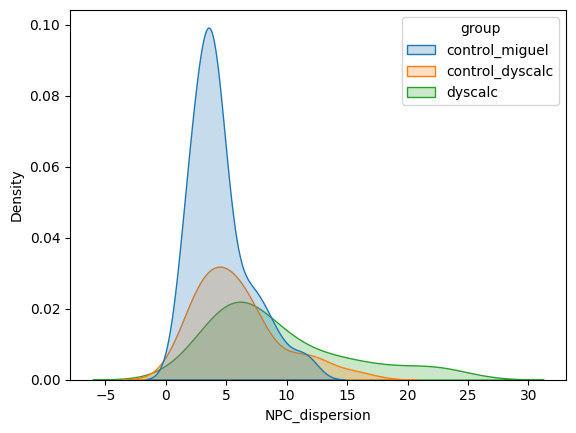

In [63]:
tmp = df_behave.join(df_neuro['group'])
sns.kdeplot(data=df_neuro, x='NPC_dispersion', hue='group', fill=True)

## Combine Neuro & Behave  and correlate

In [64]:
df_comb = df_behave.join(df_neuro)
df_comb.head()

,,perceptual_noise_sd,memory_noise_sd,NPC_dispersion,NPC_centroid,group
subject,dataset,,,,,
1,miguel,0.119338,0.164649,NaN,NaN,NaN
2,miguel,0.144083,0.141128,3.576422,1.238944,control_miguel
3,miguel,0.159790,0.204653,6.563879,1.519308,control_miguel
4,miguel,0.165733,0.240002,1.920423,1.481296,control_miguel
5,miguel,0.145187,0.252977,5.644927,2.189734,control_miguel


/tmp/ipykernel_1776448/2134629232.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_1776448/2134629232.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 5)


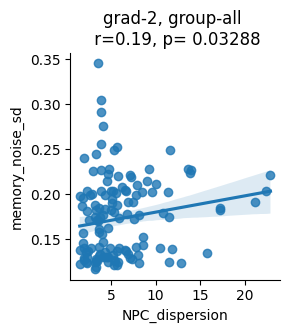

In [31]:
y_var = 'memory_noise_sd' #'perceptual_noise_sd' # 'Percent Correct'# _unbiased 'memory_noise_sd_unbiased
x_var = 'NPC_dispersion'

group = 'all' # 1 # 

import pingouin
tmp = df_comb.xs(group, level='group') if group != 'all' else df_comb #.drop(46, level='subject') # sub-46 drives effect !
cor = pingouin.corr(tmp[y_var], tmp[x_var], method = 'spearman') # shepherd,spearman,pearson || defautl: two -sided & pearson 
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)

fig = sns.lmplot(x=x_var, y=y_var, data=tmp,height=3, robust=True) #  hue='group',
fig.set(title=f'grad-{n_grad}, group-{group} \n r={r_}, p= {p}' ) 

# pearson got effect but only when sub-46 is included --> not robust to outliers

## prelim results:

without dyscalc-group-biased effect for memory_noise no correlation survives 